# Exploring a Portfolio Risk Surface

**Multivariable Calculus for Quantitative Risk Analysis**

This notebook analyzes a portfolio whose value depends on two asset prices simultaneously. We build the geometric intuition that underpins quantitative risk management: partial derivatives (delta), directional derivatives, the Hessian matrix (gamma), and Taylor approximations.

## Overview

A portfolio with multiple assets lives on a **surface** in higher-dimensional space. Understanding this surface locally—how it slopes, curves, and responds to combined market moves—is the foundation of risk management.

### Mathematical Framework

We analyze a portfolio value function:

$$V(S_1, S_2) = w_1 S_1 + w_2 S_2 + \phi(S_1, S_2)$$

where:
- $S_1, S_2$ are asset prices
- $w_1 = 100, w_2 = 80$ are position sizes (shares held)
- $\phi(S_1, S_2) = 50 \sin\left(\frac{S_1}{20}\right) \cos\left(\frac{S_2}{20}\right)$ is a nonlinear interaction term

The nonlinear term $\phi$ captures effects from derivatives, correlation dynamics, or nonlinear funding costs. Our goal is to analyze how this surface behaves locally around a reference point.

## 1. Environment Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
np.set_printoptions(precision=4, suppress=True)

# Color palette
COLORS = {
    'primary': '#2ecc71',
    'secondary': '#3498db',
    'accent': '#e74c3c',
    'neutral': '#95a5a6',
    'purple': '#9b59b6',
}

print("Environment configured successfully.")
print(f"NumPy version: {np.__version__}")

Environment configured successfully.
NumPy version: 1.26.4


## 2. The Portfolio Value Surface

### The Problem

You hold a portfolio with two assets. The portfolio value depends on both prices:

$$V(S_1, S_2) = \underbrace{w_1 S_1 + w_2 S_2}_{\text{linear (stock positions)}} + \underbrace{k \sin\left(\frac{S_1}{20}\right) \cos\left(\frac{S_2}{20}\right)}_{\text{nonlinear (derivatives/correlations)}}$$

The linear part is straightforward—it's just the value of your stock holdings. The nonlinear term $\phi$ makes the surface curved, which is where the interesting risk dynamics emerge.

### Key Questions

1. How does $V$ change when $S_1$ moves alone? When $S_2$ moves alone?
2. What happens when both assets move together?
3. Which direction gives the maximum change in portfolio value?
4. How curved is the surface? Does the sensitivity itself change?

In [2]:
# Portfolio parameters
W1 = 100        # Position in asset 1 (shares)
W2 = 80         # Position in asset 2 (shares)
K = 50          # Nonlinear interaction strength

# Reference point for local analysis
S1_STAR = 100   # Asset 1 price
S2_STAR = 100   # Asset 2 price


def portfolio_value(s1, s2, w1=W1, w2=W2, k=K):
    """
    Compute portfolio value V(S1, S2).
    
    V = w1*S1 + w2*S2 + k*sin(S1/20)*cos(S2/20)
    
    Args:
        s1: Asset 1 price (scalar or array)
        s2: Asset 2 price (scalar or array)
        w1: Position in asset 1
        w2: Position in asset 2
        k: Nonlinear interaction strength
    
    Returns:
        Portfolio value V
    """
    linear_part = w1 * s1 + w2 * s2
    phi = k * np.sin(s1 / 20) * np.cos(s2 / 20)
    return linear_part + phi


# Evaluate at reference point
V_star = portfolio_value(S1_STAR, S2_STAR)

print("=" * 60)
print("PORTFOLIO VALUE SURFACE")
print("=" * 60)
print(f"\nParameters:")
print(f"  w₁ (asset 1 position):  {W1} shares")
print(f"  w₂ (asset 2 position):  {W2} shares")
print(f"  k (nonlinear strength): {K}")
print(f"\nReference Point:")
print(f"  (S₁*, S₂*) = ({S1_STAR}, {S2_STAR})")
print(f"  V(S₁*, S₂*) = ${V_star:,.2f}")
print(f"\nPortfolio Composition at Reference:")
print(f"  Linear component: ${W1 * S1_STAR + W2 * S2_STAR:,.2f}")
print(f"  Nonlinear φ term: ${K * np.sin(S1_STAR/20) * np.cos(S2_STAR/20):,.2f}")

PORTFOLIO VALUE SURFACE

Parameters:
  w₁ (asset 1 position):  100 shares
  w₂ (asset 2 position):  80 shares
  k (nonlinear strength): 50

Reference Point:
  (S₁*, S₂*) = (100, 100)
  V(S₁*, S₂*) = $17,986.40

Portfolio Composition at Reference:
  Linear component: $18,000.00
  Nonlinear φ term: $-13.60


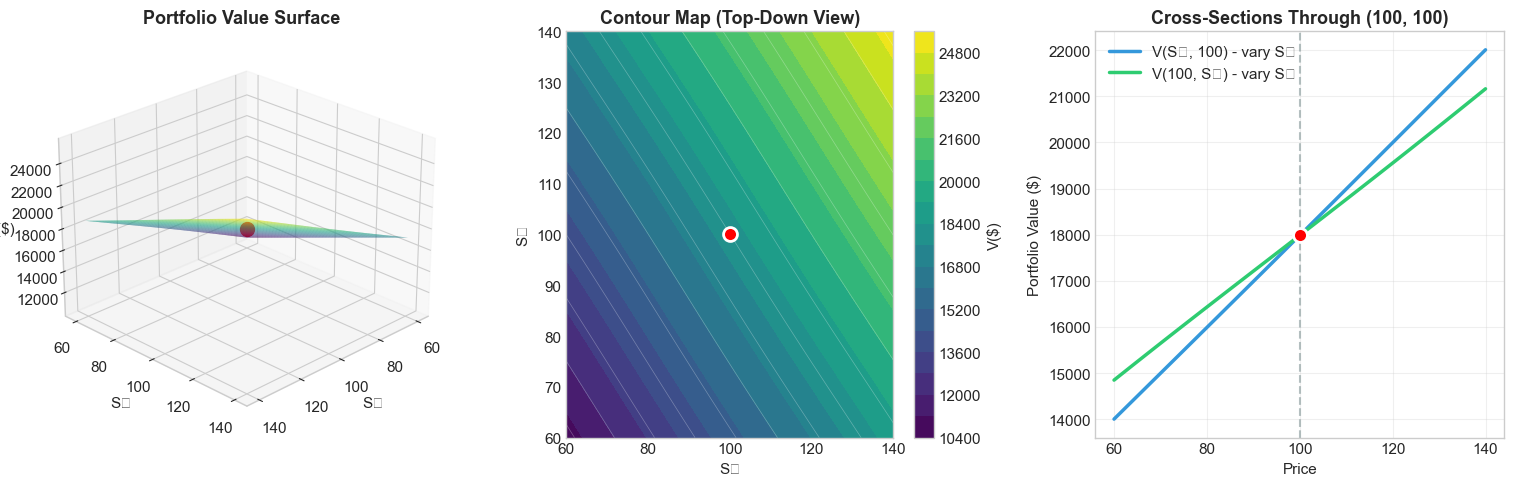


Key Observations:
• The surface is NOT a plane—it has subtle waviness from the nonlinear φ term
• Contour lines show constant-value paths (where your wealth doesn't change)
• Cross-sections reveal different slopes for each asset (asymmetric sensitivity)


In [3]:
# Visualize the surface
fig = plt.figure(figsize=(15, 5))

# Create grid for evaluation
s1_range = np.linspace(60, 140, 100)
s2_range = np.linspace(60, 140, 100)
S1, S2 = np.meshgrid(s1_range, s2_range)
V = portfolio_value(S1, S2)

# Left: 3D surface
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(S1, S2, V, cmap='viridis', alpha=0.8, linewidth=0)
ax1.scatter([S1_STAR], [S2_STAR], [V_star], color='red', s=100, zorder=5)
ax1.set_xlabel('S₁')
ax1.set_ylabel('S₂')
ax1.set_zlabel('V($)')
ax1.set_title('Portfolio Value Surface', fontweight='bold')
ax1.view_init(elev=25, azim=45)

# Center: Contour plot (top-down view)
ax2 = fig.add_subplot(132)
contour = ax2.contourf(S1, S2, V, levels=20, cmap='viridis')
ax2.contour(S1, S2, V, levels=15, colors='white', alpha=0.3, linewidths=0.5)
ax2.scatter([S1_STAR], [S2_STAR], color='red', s=100, zorder=5, edgecolors='white', linewidth=2)
ax2.set_xlabel('S₁')
ax2.set_ylabel('S₂')
ax2.set_title('Contour Map (Top-Down View)', fontweight='bold')
plt.colorbar(contour, ax=ax2, label='V($)')

# Right: Cross-sections
ax3 = fig.add_subplot(133)
V_s1_slice = portfolio_value(s1_range, S2_STAR)  # Fix S2, vary S1
V_s2_slice = portfolio_value(S1_STAR, s1_range)  # Fix S1, vary S2

ax3.plot(s1_range, V_s1_slice, color=COLORS['secondary'], linewidth=2.5, 
         label=f'V(S₁, {S2_STAR}) - vary S₁')
ax3.plot(s1_range, V_s2_slice, color=COLORS['primary'], linewidth=2.5, 
         label=f'V({S1_STAR}, S₂) - vary S₂')
ax3.axvline(S1_STAR, color=COLORS['neutral'], linestyle='--', alpha=0.7)
ax3.scatter([S1_STAR], [V_star], color='red', s=100, zorder=5, edgecolors='white', linewidth=2)
ax3.set_xlabel('Price')
ax3.set_ylabel('Portfolio Value ($)')
ax3.set_title('Cross-Sections Through (100, 100)', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("• The surface is NOT a plane—it has subtle waviness from the nonlinear φ term")
print("• Contour lines show constant-value paths (where your wealth doesn't change)")
print("• Cross-sections reveal different slopes for each asset (asymmetric sensitivity)")

## 3. Partial Derivatives (Delta)

### The Mathematics

The **partial derivative** $\frac{\partial V}{\partial S_1}$ measures how $V$ changes when only $S_1$ changes, holding $S_2$ fixed.

For our portfolio:

$$\frac{\partial V}{\partial S_1} = w_1 + \frac{k}{20} \cos\left(\frac{S_1}{20}\right) \cos\left(\frac{S_2}{20}\right)$$

$$\frac{\partial V}{\partial S_2} = w_2 - \frac{k}{20} \sin\left(\frac{S_1}{20}\right) \sin\left(\frac{S_2}{20}\right)$$

In finance, these are called **deltas**—your sensitivity to each underlying asset.

In [4]:
def compute_gradient(s1, s2, w1=W1, w2=W2, k=K):
    """
    Compute the gradient (vector of partial derivatives) at a point.
    
    ∇V = (∂V/∂S₁, ∂V/∂S₂)
    
    Returns:
        numpy array [dV/dS1, dV/dS2]
    """
    dV_dS1 = w1 + (k / 20) * np.cos(s1 / 20) * np.cos(s2 / 20)
    dV_dS2 = w2 - (k / 20) * np.sin(s1 / 20) * np.sin(s2 / 20)
    return np.array([dV_dS1, dV_dS2])


# Compute at reference point
grad = compute_gradient(S1_STAR, S2_STAR)
grad_magnitude = np.linalg.norm(grad)
grad_direction = grad / grad_magnitude

print("=" * 60)
print("PARTIAL DERIVATIVES (DELTA)")
print("=" * 60)
print(f"\nAt reference point (S₁, S₂) = ({S1_STAR}, {S2_STAR}):")
print(f"\n  ∂V/∂S₁ = {grad[0]:.4f}")
print(f"  ∂V/∂S₂ = {grad[1]:.4f}")
print(f"\nInterpretation:")
print(f"  • A $1 increase in S₁ → portfolio gains ${grad[0]:.2f}")
print(f"  • A $1 increase in S₂ → portfolio gains ${grad[1]:.2f}")
print(f"\nGradient Vector:")
print(f"  ∇V = ({grad[0]:.4f}, {grad[1]:.4f})")
print(f"  Magnitude: ||∇V|| = {grad_magnitude:.4f}")
print(f"  Direction: ({grad_direction[0]:.4f}, {grad_direction[1]:.4f})")

PARTIAL DERIVATIVES (DELTA)

At reference point (S₁, S₂) = (100, 100):

  ∂V/∂S₁ = 100.2012
  ∂V/∂S₂ = 77.7012

Interpretation:
  • A $1 increase in S₁ → portfolio gains $100.20
  • A $1 increase in S₂ → portfolio gains $77.70

Gradient Vector:
  ∇V = (100.2012, 77.7012)
  Magnitude: ||∇V|| = 126.7980
  Direction: (0.7902, 0.6128)


In [5]:
# Verify with numerical approximation
h = 0.001  # Small perturbation

# Numerical partial derivatives
dV_dS1_numerical = (portfolio_value(S1_STAR + h, S2_STAR) - portfolio_value(S1_STAR - h, S2_STAR)) / (2 * h)
dV_dS2_numerical = (portfolio_value(S1_STAR, S2_STAR + h) - portfolio_value(S1_STAR, S2_STAR - h)) / (2 * h)

print("\nVerification (Numerical vs Analytical):")
print(f"  ∂V/∂S₁: analytical = {grad[0]:.6f}, numerical = {dV_dS1_numerical:.6f}")
print(f"  ∂V/∂S₂: analytical = {grad[1]:.6f}, numerical = {dV_dS2_numerical:.6f}")
print(f"\n  Errors: {abs(grad[0] - dV_dS1_numerical):.2e}, {abs(grad[1] - dV_dS2_numerical):.2e}")


Verification (Numerical vs Analytical):
  ∂V/∂S₁: analytical = 100.201161, numerical = 100.201161
  ∂V/∂S₂: analytical = 77.701161, numerical = 77.701161

  Errors: 1.71e-09, 2.81e-09


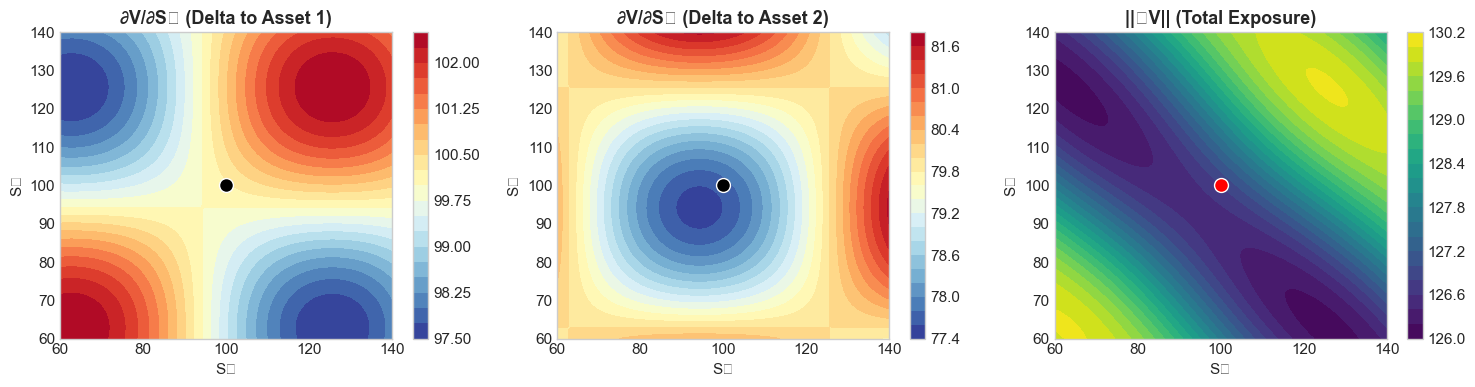


Key Insight: Deltas are NOT constant—they vary across the surface.
This is why second-order analysis (gamma) matters for risk management.


In [6]:
# Visualize how deltas change across the surface
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Compute gradients across the grid
dV_dS1_grid = W1 + (K / 20) * np.cos(S1 / 20) * np.cos(S2 / 20)
dV_dS2_grid = W2 - (K / 20) * np.sin(S1 / 20) * np.sin(S2 / 20)

# Left: Delta to S1
im1 = axes[0].contourf(S1, S2, dV_dS1_grid, levels=20, cmap='RdYlBu_r')
axes[0].scatter([S1_STAR], [S2_STAR], color='black', s=100, zorder=5, edgecolors='white')
axes[0].set_xlabel('S₁')
axes[0].set_ylabel('S₂')
axes[0].set_title('∂V/∂S₁ (Delta to Asset 1)', fontweight='bold')
plt.colorbar(im1, ax=axes[0])

# Center: Delta to S2
im2 = axes[1].contourf(S1, S2, dV_dS2_grid, levels=20, cmap='RdYlBu_r')
axes[1].scatter([S1_STAR], [S2_STAR], color='black', s=100, zorder=5, edgecolors='white')
axes[1].set_xlabel('S₁')
axes[1].set_ylabel('S₂')
axes[1].set_title('∂V/∂S₂ (Delta to Asset 2)', fontweight='bold')
plt.colorbar(im2, ax=axes[1])

# Right: Gradient magnitude
grad_mag_grid = np.sqrt(dV_dS1_grid**2 + dV_dS2_grid**2)
im3 = axes[2].contourf(S1, S2, grad_mag_grid, levels=20, cmap='viridis')
axes[2].scatter([S1_STAR], [S2_STAR], color='red', s=100, zorder=5, edgecolors='white')
axes[2].set_xlabel('S₁')
axes[2].set_ylabel('S₂')
axes[2].set_title('||∇V|| (Total Exposure)', fontweight='bold')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

print("\nKey Insight: Deltas are NOT constant—they vary across the surface.")
print("This is why second-order analysis (gamma) matters for risk management.")

## 4. Directional Derivatives and the Gradient

### The Problem

Markets don't move one asset at a time. When the Fed announces a rate decision, **both** assets might move together. The partial derivatives alone can't tell you what happens.

### The Solution: Directional Derivative

For a unit vector $\mathbf{u} = (u_1, u_2)$, the **directional derivative** is:

$$D_{\mathbf{u}} V = \nabla V \cdot \mathbf{u} = \frac{\partial V}{\partial S_1} u_1 + \frac{\partial V}{\partial S_2} u_2$$

This tells you the rate of change of $V$ when you move in direction $\mathbf{u}$.

### Key Properties

1. **Maximum change**: Moving in the gradient direction $\nabla V$ gives the largest rate of change
2. **Zero change**: Moving perpendicular to the gradient keeps $V$ constant (contour direction)
3. **The gradient magnitude** $||\nabla V||$ is the maximum directional derivative

In [7]:
def directional_derivative(s1, s2, direction):
    """
    Compute the directional derivative of V in a given direction.
    
    D_u V = ∇V · u  (dot product with unit vector)
    
    Args:
        s1, s2: Point at which to evaluate
        direction: Tuple (d1, d2) specifying the direction
    
    Returns:
        The directional derivative (scalar)
    """
    d1, d2 = direction
    
    # Normalize to unit vector
    magnitude = np.sqrt(d1**2 + d2**2)
    u1, u2 = d1 / magnitude, d2 / magnitude
    
    # Get gradient
    grad = compute_gradient(s1, s2)
    
    # Dot product
    return np.dot(grad, [u1, u2])


# Analyze sensitivity in different market scenarios
scenarios = [
    ("S₁ up only (East)", (1, 0)),
    ("S₂ up only (North)", (0, 1)),
    ("Both up equally (Northeast)", (1, 1)),
    ("S₁ down, S₂ up (Northwest)", (-1, 1)),
    ("S₁ up, S₂ down (Southeast)", (1, -1)),
    ("Gradient direction (max gain)", tuple(grad)),
    ("Perpendicular to gradient (zero change)", (-grad[1], grad[0])),
]

print("=" * 70)
print("DIRECTIONAL DERIVATIVES AT (100, 100)")
print("=" * 70)
print(f"\n{'Scenario':<40} {'Direction':<20} {'D_u V':>10}")
print("-" * 70)

for name, direction in scenarios:
    D_u = directional_derivative(S1_STAR, S2_STAR, direction)
    d_norm = np.array(direction) / np.linalg.norm(direction)
    print(f"{name:<40} ({d_norm[0]:+.3f}, {d_norm[1]:+.3f})   {D_u:>+10.2f}")

print(f"\nMaximum possible rate of change: ||∇V|| = {grad_magnitude:.2f}")
print(f"This occurs in the gradient direction: ({grad_direction[0]:.3f}, {grad_direction[1]:.3f})")

DIRECTIONAL DERIVATIVES AT (100, 100)

Scenario                                 Direction                 D_u V
----------------------------------------------------------------------
S₁ up only (East)                        (+1.000, +0.000)      +100.20
S₂ up only (North)                       (+0.000, +1.000)       +77.70
Both up equally (Northeast)              (+0.707, +0.707)      +125.80
S₁ down, S₂ up (Northwest)               (-0.707, +0.707)       -15.91
S₁ up, S₂ down (Southeast)               (+0.707, -0.707)       +15.91
Gradient direction (max gain)            (+0.790, +0.613)      +126.80
Perpendicular to gradient (zero change)  (-0.613, +0.790)        +0.00

Maximum possible rate of change: ||∇V|| = 126.80
This occurs in the gradient direction: (0.790, 0.613)


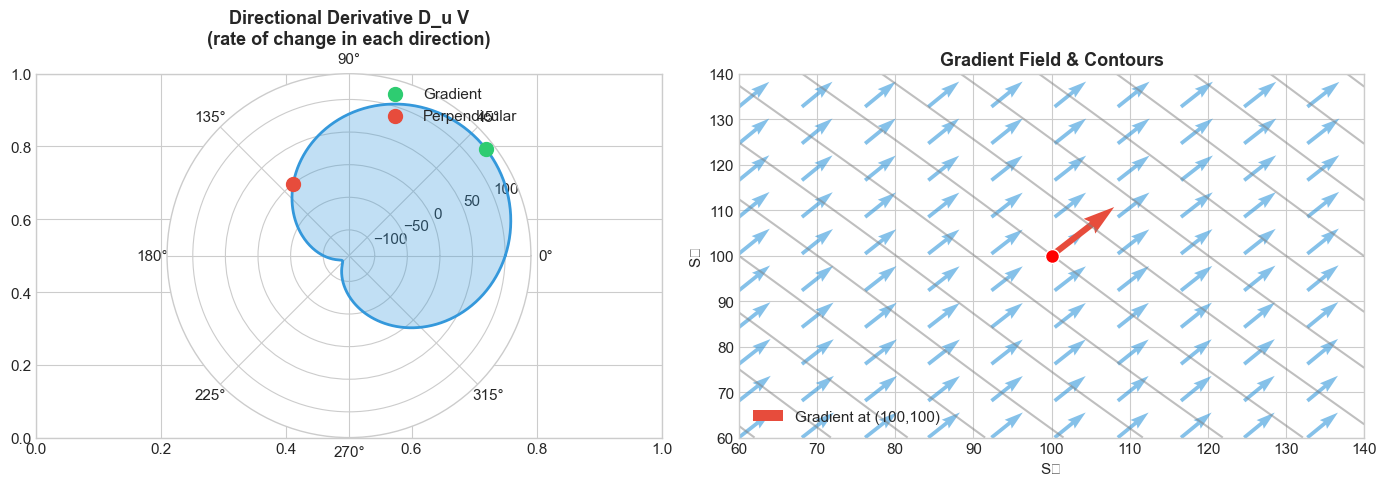


Key Insights:
• The polar plot shows D_u V as a function of direction angle
• Maximum (green dot) is in the gradient direction
• Zero crossing (red dot) is perpendicular—moving along contours
• Gradients are always perpendicular to contour lines


In [8]:
# Visualize directional derivatives as a polar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Polar plot of directional derivative
theta = np.linspace(0, 2 * np.pi, 360)
D_u_values = [directional_derivative(S1_STAR, S2_STAR, (np.cos(t), np.sin(t))) for t in theta]

ax_polar = plt.subplot(121, projection='polar')
ax_polar.plot(theta, D_u_values, color=COLORS['secondary'], linewidth=2)
ax_polar.fill(theta, D_u_values, alpha=0.3, color=COLORS['secondary'])
ax_polar.set_title('Directional Derivative D_u V\n(rate of change in each direction)', fontweight='bold')

# Mark key directions
grad_angle = np.arctan2(grad[1], grad[0])
perp_angle = grad_angle + np.pi/2
ax_polar.scatter([grad_angle], [grad_magnitude], color=COLORS['primary'], s=100, zorder=5, label='Gradient')
ax_polar.scatter([perp_angle], [0], color=COLORS['accent'], s=100, zorder=5, label='Perpendicular')
ax_polar.legend(loc='upper right')

# Right: Vector field with gradient
ax2 = plt.subplot(122)
ax2.contour(S1, S2, V, levels=15, colors='gray', alpha=0.5)

# Subsample for cleaner quiver plot
skip = 10
ax2.quiver(S1[::skip, ::skip], S2[::skip, ::skip], 
           dV_dS1_grid[::skip, ::skip], dV_dS2_grid[::skip, ::skip],
           color=COLORS['secondary'], alpha=0.6, scale=2000)

# Highlight reference point gradient
ax2.quiver([S1_STAR], [S2_STAR], [grad[0]], [grad[1]], 
           color=COLORS['accent'], scale=1000, width=0.01, label='Gradient at (100,100)')
ax2.scatter([S1_STAR], [S2_STAR], color='red', s=100, zorder=5, edgecolors='white')

ax2.set_xlabel('S₁')
ax2.set_ylabel('S₂')
ax2.set_title('Gradient Field & Contours', fontweight='bold')
ax2.legend()
ax2.set_xlim(60, 140)
ax2.set_ylim(60, 140)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("• The polar plot shows D_u V as a function of direction angle")
print("• Maximum (green dot) is in the gradient direction")
print("• Zero crossing (red dot) is perpendicular—moving along contours")
print("• Gradients are always perpendicular to contour lines")

## 5. The Hessian Matrix (Gamma)

### Why Second Derivatives Matter

The gradient tells you the current slope, but **the slope itself changes** as you move. The **Hessian matrix** captures this:

$$H = \begin{pmatrix} \frac{\partial^2 V}{\partial S_1^2} & \frac{\partial^2 V}{\partial S_1 \partial S_2} \\ \frac{\partial^2 V}{\partial S_2 \partial S_1} & \frac{\partial^2 V}{\partial S_2^2} \end{pmatrix}$$

For our portfolio:

$$\frac{\partial^2 V}{\partial S_1^2} = -\frac{k}{400} \sin\left(\frac{S_1}{20}\right) \cos\left(\frac{S_2}{20}\right)$$

$$\frac{\partial^2 V}{\partial S_2^2} = -\frac{k}{400} \sin\left(\frac{S_1}{20}\right) \cos\left(\frac{S_2}{20}\right)$$

$$\frac{\partial^2 V}{\partial S_1 \partial S_2} = -\frac{k}{400} \cos\left(\frac{S_1}{20}\right) \sin\left(\frac{S_2}{20}\right)$$

In finance, second derivatives are called **gamma**—how fast your delta changes.

In [9]:
def compute_hessian(s1, s2, k=K):
    """
    Compute the Hessian matrix of V at a point.
    
    Returns:
        2x2 numpy array representing the Hessian
    """
    h11 = -(k / 400) * np.sin(s1 / 20) * np.cos(s2 / 20)
    h22 = -(k / 400) * np.sin(s1 / 20) * np.cos(s2 / 20)
    h12 = -(k / 400) * np.cos(s1 / 20) * np.sin(s2 / 20)
    
    return np.array([[h11, h12], [h12, h22]])


# Compute Hessian at reference point
H = compute_hessian(S1_STAR, S2_STAR)

# Eigenvalue decomposition
eigenvalues, eigenvectors = np.linalg.eigh(H)

# Sort by magnitude (largest first)
idx = np.argsort(np.abs(eigenvalues))[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("=" * 60)
print("HESSIAN MATRIX (GAMMA)")
print("=" * 60)
print(f"\nAt reference point (S₁, S₂) = ({S1_STAR}, {S2_STAR}):")
print(f"\nHessian matrix H:")
print(f"  [{H[0,0]:+.6f}  {H[0,1]:+.6f}]")
print(f"  [{H[1,0]:+.6f}  {H[1,1]:+.6f}]")
print(f"\nEigenvalue Decomposition:")
print(f"  λ₁ = {eigenvalues[0]:+.6f}  (principal curvature 1)")
print(f"  λ₂ = {eigenvalues[1]:+.6f}  (principal curvature 2)")
print(f"\nPrincipal Directions:")
print(f"  v₁ = ({eigenvectors[0,0]:+.4f}, {eigenvectors[1,0]:+.4f})")
print(f"  v₂ = ({eigenvectors[0,1]:+.4f}, {eigenvectors[1,1]:+.4f})")

HESSIAN MATRIX (GAMMA)

At reference point (S₁, S₂) = (100, 100):

Hessian matrix H:
  [+0.034001  +0.034001]
  [+0.034001  +0.034001]

Eigenvalue Decomposition:
  λ₁ = +0.068003  (principal curvature 1)
  λ₂ = +0.000000  (principal curvature 2)

Principal Directions:
  v₁ = (+0.7071, +0.7071)
  v₂ = (-0.7071, +0.7071)


In [10]:
# Interpret the eigenvalues
print("\n" + "=" * 60)
print("GEOMETRIC INTERPRETATION")
print("=" * 60)

# Determine surface shape
if eigenvalues[0] > 0 and eigenvalues[1] > 0:
    shape = "Bowl (local minimum) - curves upward in all directions"
elif eigenvalues[0] < 0 and eigenvalues[1] < 0:
    shape = "Inverted bowl (local maximum) - curves downward in all directions"
elif eigenvalues[0] * eigenvalues[1] < 0:
    shape = "Saddle - curves up in one direction, down in another"
elif abs(eigenvalues[1]) < 1e-10:
    if eigenvalues[0] > 0:
        shape = "Trough (parabolic cylinder) - curves upward in one direction, flat in another"
    else:
        shape = "Ridge (parabolic cylinder) - curves downward in one direction, flat in another"
else:
    shape = "Approximately flat"

print(f"\nSurface shape at ({S1_STAR}, {S2_STAR}): {shape}")
print(f"\nCurvature Analysis:")
print(f"  • Direction ({eigenvectors[0,0]:+.3f}, {eigenvectors[1,0]:+.3f}): curvature = {eigenvalues[0]:.4f}")
print(f"  • Direction ({eigenvectors[0,1]:+.3f}, {eigenvectors[1,1]:+.3f}): curvature = {eigenvalues[1]:.4f}")

# Quadratic correction example
distance = 10
quadratic_correction = 0.5 * eigenvalues[0] * distance**2
print(f"\nQuadratic Correction Example:")
print(f"  Moving {distance} units in principal direction 1:")
print(f"  Second-order term = ½ × λ₁ × d² = ½ × {eigenvalues[0]:.4f} × {distance}² = ${quadratic_correction:.2f}")


GEOMETRIC INTERPRETATION

Surface shape at (100, 100): Trough (parabolic cylinder) - curves upward in one direction, flat in another

Curvature Analysis:
  • Direction (+0.707, +0.707): curvature = 0.0680
  • Direction (-0.707, +0.707): curvature = 0.0000

Quadratic Correction Example:
  Moving 10 units in principal direction 1:
  Second-order term = ½ × λ₁ × d² = ½ × 0.0680 × 10² = $3.40


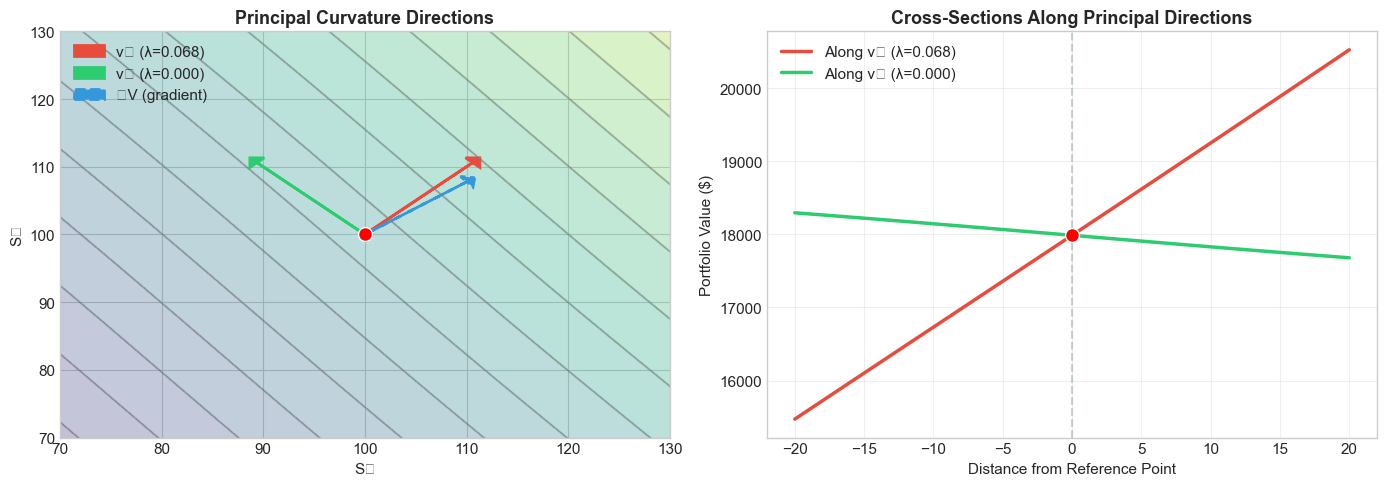


Key Insight: The surface curves differently in different directions.
Eigenvalues tell you the curvature magnitude; eigenvectors tell you the direction.


In [11]:
# Visualize curvature with principal directions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Contours with principal directions
ax1 = axes[0]
ax1.contour(S1, S2, V, levels=20, colors='gray', alpha=0.5)
ax1.contourf(S1, S2, V, levels=20, cmap='viridis', alpha=0.3)

# Draw principal directions
scale = 15
ax1.arrow(S1_STAR, S2_STAR, eigenvectors[0,0]*scale, eigenvectors[1,0]*scale,
          head_width=2, head_length=1, fc=COLORS['accent'], ec=COLORS['accent'],
          linewidth=2, label=f'v₁ (λ={eigenvalues[0]:.3f})')
ax1.arrow(S1_STAR, S2_STAR, eigenvectors[0,1]*scale, eigenvectors[1,1]*scale,
          head_width=2, head_length=1, fc=COLORS['primary'], ec=COLORS['primary'],
          linewidth=2, label=f'v₂ (λ={eigenvalues[1]:.3f})')

# Also show gradient
grad_scale = 0.1
ax1.arrow(S1_STAR, S2_STAR, grad[0]*grad_scale, grad[1]*grad_scale,
          head_width=2, head_length=1, fc=COLORS['secondary'], ec=COLORS['secondary'],
          linewidth=2, linestyle='--', label='∇V (gradient)')

ax1.scatter([S1_STAR], [S2_STAR], color='red', s=100, zorder=5, edgecolors='white')
ax1.set_xlabel('S₁')
ax1.set_ylabel('S₂')
ax1.set_title('Principal Curvature Directions', fontweight='bold')
ax1.legend(loc='upper left')
ax1.set_xlim(70, 130)
ax1.set_ylim(70, 130)

# Right: Cross-section curvature visualization
ax2 = axes[1]
t = np.linspace(-20, 20, 100)

# Cross-section along principal direction 1
s1_v1 = S1_STAR + t * eigenvectors[0, 0]
s2_v1 = S2_STAR + t * eigenvectors[1, 0]
V_v1 = portfolio_value(s1_v1, s2_v1)

# Cross-section along principal direction 2
s1_v2 = S1_STAR + t * eigenvectors[0, 1]
s2_v2 = S2_STAR + t * eigenvectors[1, 1]
V_v2 = portfolio_value(s1_v2, s2_v2)

ax2.plot(t, V_v1, color=COLORS['accent'], linewidth=2.5, label=f'Along v₁ (λ={eigenvalues[0]:.3f})')
ax2.plot(t, V_v2, color=COLORS['primary'], linewidth=2.5, label=f'Along v₂ (λ={eigenvalues[1]:.3f})')
ax2.axvline(0, color=COLORS['neutral'], linestyle='--', alpha=0.5)
ax2.scatter([0], [V_star], color='red', s=100, zorder=5, edgecolors='white')

ax2.set_xlabel('Distance from Reference Point')
ax2.set_ylabel('Portfolio Value ($)')
ax2.set_title('Cross-Sections Along Principal Directions', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insight: The surface curves differently in different directions.")
print("Eigenvalues tell you the curvature magnitude; eigenvectors tell you the direction.")

## 6. Taylor Approximations

### The Power of Local Approximation

You can't recompute the full surface every time markets move. Taylor expansions give fast local approximations.

### First-Order (Linear) Approximation

The tangent plane at $(S_1^*, S_2^*)$:

$$V(S_1, S_2) \approx V^* + \frac{\partial V}{\partial S_1}(S_1 - S_1^*) + \frac{\partial V}{\partial S_2}(S_2 - S_2^*)$$

In vector notation: $V \approx V^* + \nabla V^T \Delta S$

### Second-Order (Quadratic) Approximation

Adding curvature correction:

$$V \approx V^* + \nabla V^T \Delta S + \frac{1}{2} \Delta S^T H \Delta S$$

where $\Delta S = (S_1 - S_1^*, S_2 - S_2^*)^T$

In [12]:
def taylor_approximation(s1, s2, order=2, s1_star=S1_STAR, s2_star=S2_STAR):
    """
    Taylor approximation of V around the reference point.
    
    Args:
        s1, s2: Point at which to approximate
        order: 1 for linear, 2 for quadratic
        s1_star, s2_star: Expansion point
    
    Returns:
        Approximate portfolio value
    """
    V_star = portfolio_value(s1_star, s2_star)
    grad = compute_gradient(s1_star, s2_star)
    delta = np.array([s1 - s1_star, s2 - s2_star])
    
    if order == 1:
        return V_star + np.dot(grad, delta)
    else:
        H = compute_hessian(s1_star, s2_star)
        return V_star + np.dot(grad, delta) + 0.5 * np.dot(delta, H @ delta)


# Test at several points
test_points = [
    (100, 100),   # Reference point
    (105, 98),    # Small move
    (110, 95),    # Medium move
    (120, 90),    # Larger move
    (130, 85),    # Even larger
]

print("=" * 80)
print("TAYLOR APPROXIMATION ACCURACY")
print("=" * 80)
print(f"\nExpansion point: ({S1_STAR}, {S2_STAR})")
print(f"\n{'Point':<15} {'True V':>12} {'Linear':>12} {'Quadratic':>12} {'Lin Err':>10} {'Quad Err':>10}")
print("-" * 80)

for s1, s2 in test_points:
    V_true = portfolio_value(s1, s2)
    V_linear = taylor_approximation(s1, s2, order=1)
    V_quad = taylor_approximation(s1, s2, order=2)
    
    lin_err = abs(V_true - V_linear)
    quad_err = abs(V_true - V_quad)
    
    print(f"({s1:3}, {s2:3})      ${V_true:>10,.2f}  ${V_linear:>10,.2f}  ${V_quad:>10,.2f}  ${lin_err:>8.2f}  ${quad_err:>8.2f}")

print("\nObservation: Quadratic approximation is more accurate, especially for larger moves.")

TAYLOR APPROXIMATION ACCURACY

Expansion point: (100, 100)

Point                 True V       Linear    Quadratic    Lin Err   Quad Err
--------------------------------------------------------------------------------
(100, 100)      $ 17,986.40  $ 17,986.40  $ 17,986.40  $    0.00  $    0.00
(105,  98)      $ 18,331.99  $ 18,332.00  $ 18,332.16  $    0.01  $    0.17
(110,  95)      $ 18,598.67  $ 18,599.91  $ 18,600.33  $    1.23  $    1.66
(120,  90)      $ 19,202.94  $ 19,213.41  $ 19,215.11  $   10.47  $   12.17
(130,  85)      $ 19,795.20  $ 19,826.92  $ 19,830.74  $   31.71  $   35.54

Observation: Quadratic approximation is more accurate, especially for larger moves.


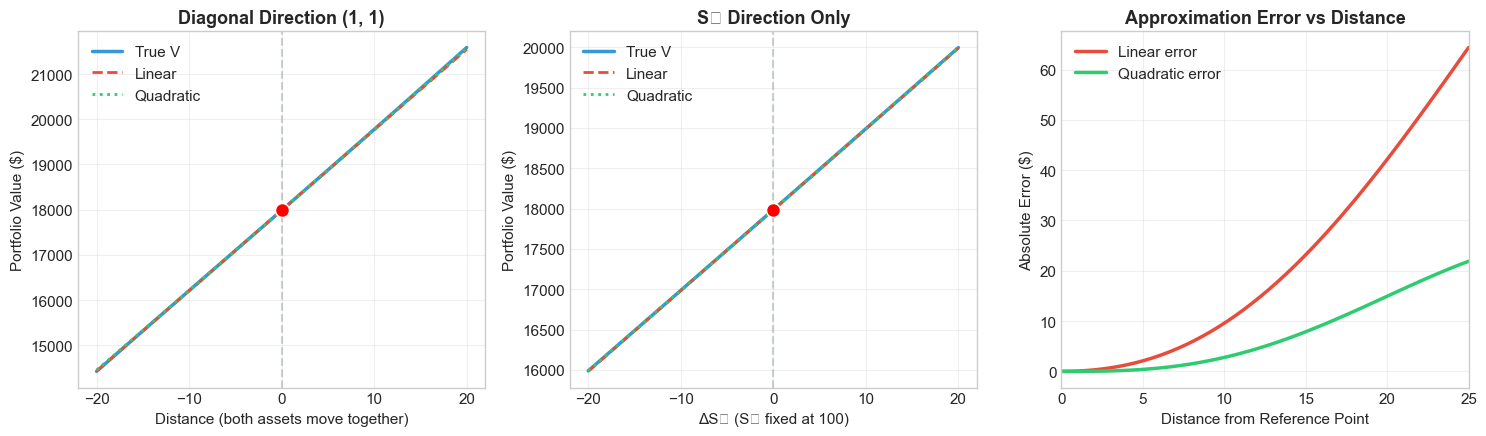


Key Insight: Linear approximation error grows as distance² (quadratically).
Quadratic approximation captures curvature and stays accurate longer.


In [13]:
# Visualize approximation accuracy
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: Along diagonal (both up)
t = np.linspace(-20, 20, 100)
s1_diag = S1_STAR + t
s2_diag = S2_STAR + t

V_true = portfolio_value(s1_diag, s2_diag)
V_lin = np.array([taylor_approximation(s1, s2, order=1) for s1, s2 in zip(s1_diag, s2_diag)])
V_quad = np.array([taylor_approximation(s1, s2, order=2) for s1, s2 in zip(s1_diag, s2_diag)])

axes[0].plot(t, V_true, color=COLORS['secondary'], linewidth=2.5, label='True V')
axes[0].plot(t, V_lin, color=COLORS['accent'], linewidth=2, linestyle='--', label='Linear')
axes[0].plot(t, V_quad, color=COLORS['primary'], linewidth=2, linestyle=':', label='Quadratic')
axes[0].axvline(0, color=COLORS['neutral'], linestyle='--', alpha=0.5)
axes[0].scatter([0], [V_star], color='red', s=100, zorder=5, edgecolors='white')
axes[0].set_xlabel('Distance (both assets move together)')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].set_title('Diagonal Direction (1, 1)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Along S1 only
s1_axis = S1_STAR + t
V_true_s1 = portfolio_value(s1_axis, S2_STAR)
V_lin_s1 = np.array([taylor_approximation(s1, S2_STAR, order=1) for s1 in s1_axis])
V_quad_s1 = np.array([taylor_approximation(s1, S2_STAR, order=2) for s1 in s1_axis])

axes[1].plot(t, V_true_s1, color=COLORS['secondary'], linewidth=2.5, label='True V')
axes[1].plot(t, V_lin_s1, color=COLORS['accent'], linewidth=2, linestyle='--', label='Linear')
axes[1].plot(t, V_quad_s1, color=COLORS['primary'], linewidth=2, linestyle=':', label='Quadratic')
axes[1].axvline(0, color=COLORS['neutral'], linestyle='--', alpha=0.5)
axes[1].scatter([0], [V_star], color='red', s=100, zorder=5, edgecolors='white')
axes[1].set_xlabel('ΔS₁ (S₂ fixed at 100)')
axes[1].set_ylabel('Portfolio Value ($)')
axes[1].set_title('S₁ Direction Only', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Error comparison
distances = np.linspace(0, 25, 50)
lin_errors = []
quad_errors = []

for d in distances:
    # Move diagonally
    s1, s2 = S1_STAR + d, S2_STAR + d
    V_true = portfolio_value(s1, s2)
    V_lin = taylor_approximation(s1, s2, order=1)
    V_quad = taylor_approximation(s1, s2, order=2)
    lin_errors.append(abs(V_true - V_lin))
    quad_errors.append(abs(V_true - V_quad))

axes[2].plot(distances, lin_errors, color=COLORS['accent'], linewidth=2.5, label='Linear error')
axes[2].plot(distances, quad_errors, color=COLORS['primary'], linewidth=2.5, label='Quadratic error')
axes[2].set_xlabel('Distance from Reference Point')
axes[2].set_ylabel('Absolute Error ($)')
axes[2].set_title('Approximation Error vs Distance', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 25)

plt.tight_layout()
plt.show()

print("\nKey Insight: Linear approximation error grows as distance² (quadratically).")
print("Quadratic approximation captures curvature and stays accurate longer.")

## 7. Complete Analysis Summary

Let's bring everything together in a comprehensive risk report.

In [14]:
# Complete summary
print("=" * 70)
print("PORTFOLIO RISK SURFACE ANALYSIS - COMPLETE SUMMARY")
print("=" * 70)

print(f"\n{'─' * 70}")
print("PORTFOLIO SPECIFICATION")
print(f"{'─' * 70}")
print(f"  V(S₁, S₂) = {W1}·S₁ + {W2}·S₂ + {K}·sin(S₁/20)·cos(S₂/20)")
print(f"  Reference point: (S₁*, S₂*) = ({S1_STAR}, {S2_STAR})")
print(f"  Portfolio value at reference: V* = ${V_star:,.2f}")

print(f"\n{'─' * 70}")
print("FIRST-ORDER ANALYSIS (DELTA)")
print(f"{'─' * 70}")
print(f"  ∂V/∂S₁ = {grad[0]:.4f}  →  $1 move in S₁ changes V by ${grad[0]:.2f}")
print(f"  ∂V/∂S₂ = {grad[1]:.4f}  →  $1 move in S₂ changes V by ${grad[1]:.2f}")
print(f"  ∇V = ({grad[0]:.4f}, {grad[1]:.4f})")
print(f"  ||∇V|| = {grad_magnitude:.4f} (maximum directional derivative)")
print(f"  Steepest ascent: direction ({grad_direction[0]:.4f}, {grad_direction[1]:.4f})")

print(f"\n{'─' * 70}")
print("SECOND-ORDER ANALYSIS (GAMMA)")
print(f"{'─' * 70}")
print(f"  Hessian H:")
print(f"    [{H[0,0]:+.6f}  {H[0,1]:+.6f}]")
print(f"    [{H[1,0]:+.6f}  {H[1,1]:+.6f}]")
print(f"  Eigenvalues: λ₁ = {eigenvalues[0]:.6f}, λ₂ = {eigenvalues[1]:.6f}")
print(f"  Principal direction 1: ({eigenvectors[0,0]:.4f}, {eigenvectors[1,0]:.4f})")
print(f"  Principal direction 2: ({eigenvectors[0,1]:.4f}, {eigenvectors[1,1]:.4f})")
print(f"  Surface type: {shape}")

print(f"\n{'─' * 70}")
print("TAYLOR APPROXIMATION FORMULAS")
print(f"{'─' * 70}")
print(f"  First-order:  V ≈ V* + ∇V·ΔS")
print(f"  Second-order: V ≈ V* + ∇V·ΔS + ½·ΔS'·H·ΔS")
print(f"\n  At (110, 95):")
V_true_test = portfolio_value(110, 95)
V_lin_test = taylor_approximation(110, 95, order=1)
V_quad_test = taylor_approximation(110, 95, order=2)
print(f"    True value:      ${V_true_test:,.2f}")
print(f"    Linear approx:   ${V_lin_test:,.2f}  (error: ${abs(V_true_test - V_lin_test):.2f})")
print(f"    Quadratic approx:${V_quad_test:,.2f}  (error: ${abs(V_true_test - V_quad_test):.2f})")

print(f"\n{'─' * 70}")
print("RISK MANAGEMENT IMPLICATIONS")
print(f"{'─' * 70}")
print(f"  • Asset 1 is more sensitive (delta = {grad[0]:.2f} vs {grad[1]:.2f})")
print(f"  • Max exposure direction: both assets moving together")
print(f"  • Hedge direction: ({-grad[1]/grad_magnitude:.3f}, {grad[0]/grad_magnitude:.3f}) keeps V constant")
print(f"  • Curvature is positive in one direction → gains from volatility")
print(f"  • Linear approx fails for moves > ~$10 per asset")
print("=" * 70)

PORTFOLIO RISK SURFACE ANALYSIS - COMPLETE SUMMARY

──────────────────────────────────────────────────────────────────────
PORTFOLIO SPECIFICATION
──────────────────────────────────────────────────────────────────────
  V(S₁, S₂) = 100·S₁ + 80·S₂ + 50·sin(S₁/20)·cos(S₂/20)
  Reference point: (S₁*, S₂*) = (100, 100)
  Portfolio value at reference: V* = $17,986.40

──────────────────────────────────────────────────────────────────────
FIRST-ORDER ANALYSIS (DELTA)
──────────────────────────────────────────────────────────────────────
  ∂V/∂S₁ = 100.2012  →  $1 move in S₁ changes V by $100.20
  ∂V/∂S₂ = 77.7012  →  $1 move in S₂ changes V by $77.70
  ∇V = (100.2012, 77.7012)
  ||∇V|| = 126.7980 (maximum directional derivative)
  Steepest ascent: direction (0.7902, 0.6128)

──────────────────────────────────────────────────────────────────────
SECOND-ORDER ANALYSIS (GAMMA)
──────────────────────────────────────────────────────────────────────
  Hessian H:
    [+0.034001  +0.034001]
    [+0.

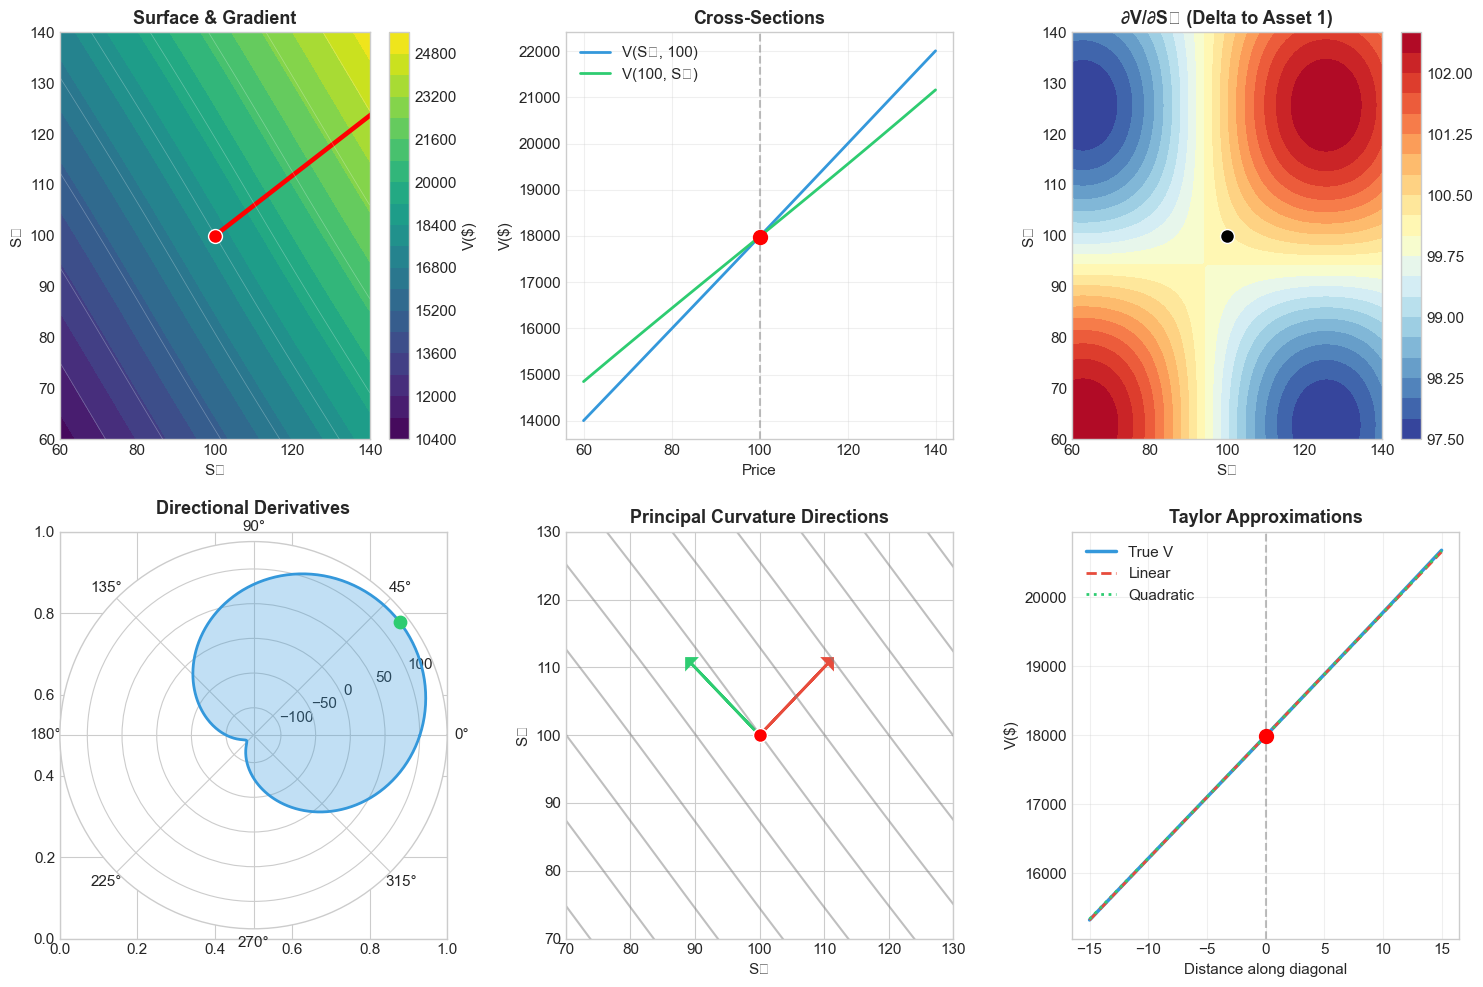

In [15]:
# Final comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Surface views
# 1.1: Heatmap with gradient
im1 = axes[0, 0].contourf(S1, S2, V, levels=20, cmap='viridis')
axes[0, 0].contour(S1, S2, V, levels=10, colors='white', alpha=0.3, linewidths=0.5)
axes[0, 0].quiver(S1_STAR, S2_STAR, grad[0]*0.3, grad[1]*0.3, color='red', scale=50, width=0.015)
axes[0, 0].scatter([S1_STAR], [S2_STAR], color='red', s=100, zorder=5, edgecolors='white')
axes[0, 0].set_xlabel('S₁')
axes[0, 0].set_ylabel('S₂')
axes[0, 0].set_title('Surface & Gradient', fontweight='bold')
plt.colorbar(im1, ax=axes[0, 0], label='V($)')

# 1.2: Cross-sections
axes[0, 1].plot(s1_range, portfolio_value(s1_range, S2_STAR), color=COLORS['secondary'], linewidth=2, label=f'V(S₁, {S2_STAR})')
axes[0, 1].plot(s1_range, portfolio_value(S1_STAR, s1_range), color=COLORS['primary'], linewidth=2, label=f'V({S1_STAR}, S₂)')
axes[0, 1].axvline(S1_STAR, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].scatter([S1_STAR], [V_star], color='red', s=100, zorder=5)
axes[0, 1].set_xlabel('Price')
axes[0, 1].set_ylabel('V($)')
axes[0, 1].set_title('Cross-Sections', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 1.3: Delta surfaces
im3 = axes[0, 2].contourf(S1, S2, dV_dS1_grid, levels=20, cmap='RdYlBu_r')
axes[0, 2].scatter([S1_STAR], [S2_STAR], color='black', s=100, zorder=5, edgecolors='white')
axes[0, 2].set_xlabel('S₁')
axes[0, 2].set_ylabel('S₂')
axes[0, 2].set_title('∂V/∂S₁ (Delta to Asset 1)', fontweight='bold')
plt.colorbar(im3, ax=axes[0, 2])

# Row 2: Analysis
# 2.1: Directional derivatives (polar)
ax_polar = plt.subplot(2, 3, 4, projection='polar')
ax_polar.plot(theta, D_u_values, color=COLORS['secondary'], linewidth=2)
ax_polar.fill(theta, D_u_values, alpha=0.3, color=COLORS['secondary'])
ax_polar.scatter([grad_angle], [grad_magnitude], color=COLORS['primary'], s=80, zorder=5)
ax_polar.set_title('Directional Derivatives', fontweight='bold', pad=20)

# 2.2: Principal directions
axes[1, 1].contour(S1, S2, V, levels=15, colors='gray', alpha=0.5)
scale = 15
axes[1, 1].arrow(S1_STAR, S2_STAR, eigenvectors[0,0]*scale, eigenvectors[1,0]*scale,
                 head_width=2, head_length=1, fc=COLORS['accent'], ec=COLORS['accent'], linewidth=2)
axes[1, 1].arrow(S1_STAR, S2_STAR, eigenvectors[0,1]*scale, eigenvectors[1,1]*scale,
                 head_width=2, head_length=1, fc=COLORS['primary'], ec=COLORS['primary'], linewidth=2)
axes[1, 1].scatter([S1_STAR], [S2_STAR], color='red', s=100, zorder=5, edgecolors='white')
axes[1, 1].set_xlabel('S₁')
axes[1, 1].set_ylabel('S₂')
axes[1, 1].set_title('Principal Curvature Directions', fontweight='bold')
axes[1, 1].set_xlim(70, 130)
axes[1, 1].set_ylim(70, 130)

# 2.3: Taylor approximation accuracy
t = np.linspace(-15, 15, 100)
V_true_diag = portfolio_value(S1_STAR + t, S2_STAR + t)
V_lin_diag = np.array([taylor_approximation(S1_STAR + ti, S2_STAR + ti, order=1) for ti in t])
V_quad_diag = np.array([taylor_approximation(S1_STAR + ti, S2_STAR + ti, order=2) for ti in t])

axes[1, 2].plot(t, V_true_diag, color=COLORS['secondary'], linewidth=2.5, label='True V')
axes[1, 2].plot(t, V_lin_diag, color=COLORS['accent'], linewidth=2, linestyle='--', label='Linear')
axes[1, 2].plot(t, V_quad_diag, color=COLORS['primary'], linewidth=2, linestyle=':', label='Quadratic')
axes[1, 2].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1, 2].scatter([0], [V_star], color='red', s=100, zorder=5)
axes[1, 2].set_xlabel('Distance along diagonal')
axes[1, 2].set_ylabel('V($)')
axes[1, 2].set_title('Taylor Approximations', fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Conclusion

This notebook demonstrated how multivariable calculus provides the foundation for quantitative risk analysis:

### Key Concepts

| Concept | Mathematics | Finance Term | Interpretation |
|---------|------------|--------------|----------------|
| Partial derivative | $\frac{\partial V}{\partial S_i}$ | **Delta** | Sensitivity to single asset |
| Gradient | $\nabla V$ | **Total exposure** | Direction of maximum change |
| Directional derivative | $D_{\mathbf{u}}V = \nabla V \cdot \mathbf{u}$ | **Scenario sensitivity** | Rate of change in any direction |
| Hessian | $H$ | **Gamma** | How delta changes |
| Eigenvalues | $\lambda_i$ | **Principal risks** | Curvature along key directions |
| Taylor expansion | $V \approx V^* + \nabla V^T \Delta S + \frac{1}{2} \Delta S^T H \Delta S$ | **Greek approximation** | Fast local valuation |

### Key Insights

1. **Partial derivatives (delta)** measure axis-aligned sensitivities, your exposure to each asset independently

2. **The gradient** points toward maximum value increase; moving perpendicular to it keeps value constant (hedging direction)

3. **The Hessian (gamma)** tells you how fast sensitivities change, crucial for large moves

4. **Eigenanalysis** reveals principal risk directions, the natural coordinate system for the surface

5. **Taylor approximations** trade accuracy for speed, first-order works locally, second-order extends the range

### What's Next

In the **Linear Algebra** module, you'll learn to work with these tools computationally, matrix operations, eigendecomposition, and covariance matrices that underpin modern portfolio theory.

---

*This notebook was created as part of the QuantFrame educational platform.*